# 05 — Training, validation, and standalone CLI

- **Mapped issue:** [#12](https://github.com/majorgilles/transformer-2017-reproduction/issues/12)
- **Depends on:** `04_objective_optimizer_batching.ipynb` / issue #11.


In [1]:
#| default_exp training


## Goal

Turn the working notebook fixture into small training and validation functions, then call them from a fresh Python process. The fresh process is the important boundary: successful execution must depend only on exported code and explicit inputs, not variables left in a notebook kernel.

This notebook reuses the Transformer from notebook 03 and label-smoothed loss from notebook 04. Checkpoint persistence, WMT orchestration, mixed precision, and the canonical campaign remain later concerns.


## One training pass

Each batch contains a source tensor shaped `(batch, source_length)` and a complete target tensor shaped `(batch, target_length + 1)`. The target is shifted into decoder inputs (`target[:, :-1]`) and next-token labels (`target[:, 1:]`). The model returns logits shaped `(batch, target_length, vocabulary_size)`; backpropagation and the optimizer then update its parameters.


In [2]:
#| export
import argparse
import json
from collections.abc import Sequence
from typing import cast

import torch

from transformer_2017_reproduction.model import Transformer
from transformer_2017_reproduction.optimization import label_smoothed_loss

In [3]:
#| export
def train(
    model: Transformer,
    batches: Sequence[tuple[torch.Tensor, torch.Tensor]],
    optimizer: torch.optim.Optimizer,
) -> float:
    """Run one parameter-updating pass and return its mean batch loss."""
    if len(batches) == 0:
        raise ValueError("Cannot compute loss on empty sequence of batches.")

    total_loss = 0.0
    model.train()
    for source_token_ids, target_token_ids in batches:
        optimizer.zero_grad()

        decoder_input_ids = target_token_ids[:, :-1]
        logits = model(
            source_token_ids=source_token_ids,
            target_token_ids=decoder_input_ids,
        )

        next_token_labels = target_token_ids[:, 1:]
        loss = label_smoothed_loss(
            logits=logits,
            targets=next_token_labels,
            pad_token_id=model.pad_token_id,
        )
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(batches)

## Training changes model parameters

A training pass should produce a finite loss and update at least one model
parameter. This small deterministic fixture checks both behaviors.

In [4]:
torch.manual_seed(0)

fixture_model = Transformer(
    vocab_size=32,
    d_model=8,
    num_heads=2,
    d_ff=16,
    max_length=8,
    pad_token_id=0,
    dropout=0.0,
    num_layers=6,
)

# This fixed learning rate is only for the one-step fixture.
fixture_optimizer = torch.optim.Adam(
    fixture_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.98),
    eps=1e-9,
)

# Each row is one source sentence.
# source_token_ids shape: (batch=1, source_length=4)
source_token_ids = torch.tensor(
    [
        [2, 5, 6, 3],
    ],
    dtype=torch.long,
)

# Complete target: BOS, two translation tokens, EOS.
# target_token_ids shape: (batch=1, complete_target_length=4)
target_token_ids = torch.tensor(
    [
        [2, 7, 8, 3],
    ],
    dtype=torch.long,
)

fixture_batches = [
    (source_token_ids, target_token_ids),
]

# clone() is necessary because model parameters are mutable.
parameters_before = [parameter.detach().clone() for parameter in fixture_model.parameters()]

training_loss = train(
    model=fixture_model,
    batches=fixture_batches,
    optimizer=fixture_optimizer,
)

parameters_changed = any(
    not torch.equal(before, after)
    for before, after in zip(
        parameters_before,
        fixture_model.parameters(),
        strict=True,
    )
)

assert torch.isfinite(torch.tensor(training_loss))
assert parameters_changed

print(f"Training loss: {training_loss:.4f}")
print(f"At least one parameter changed: {parameters_changed}")

Training loss: 5.8934
At least one parameter changed: True


## Validation measures without updating

Validation performs the same target shift, forward pass, and loss calculation as training, but it does not calculate gradients or call an optimizer. `model.eval()` selects evaluation behavior such as disabled dropout, while `@torch.no_grad()` prevents construction of a gradient graph.


In [5]:
#| export
@torch.no_grad()
def validate(
    model: Transformer,
    batches: Sequence[tuple[torch.Tensor, torch.Tensor]],
) -> float:
    """Return mean batch loss in evaluation mode without gradients."""
    if len(batches) == 0:
        raise ValueError("Cannot compute loss on empty sequence of batches.")

    total_loss = 0.0
    model.eval()
    for source_token_ids, target_token_ids in batches:
        decoder_input_ids = target_token_ids[:, :-1]
        logits = model(
            source_token_ids=source_token_ids,
            target_token_ids=decoder_input_ids,
        )

        next_token_labels = target_token_ids[:, 1:]
        loss = label_smoothed_loss(
            logits=logits,
            targets=next_token_labels,
            pad_token_id=model.pad_token_id,
        )
        total_loss += loss.item()

    return total_loss / len(batches)

### Validation preserves model parameters

Validation should return a finite loss while leaving every model parameter unchanged.

In [6]:
parameters_before_validation = [
    parameter.detach().clone() for parameter in fixture_model.parameters()
]

validation_loss = validate(
    model=fixture_model,
    batches=fixture_batches,
)

parameters_unchanged = all(
    torch.equal(before, after)
    for before, after in zip(
        parameters_before_validation,
        fixture_model.parameters(),
        strict=True,
    )
)

assert torch.isfinite(torch.tensor(validation_loss))
assert parameters_unchanged
assert not fixture_model.training

print(f"Validation loss: {validation_loss:.4f}")
print(f"All parameters unchanged: {parameters_unchanged}")

Validation loss: 5.1963
All parameters unchanged: True


## Repeated passes produce a learning curve

This deterministic fixture uses the same tiny data for training and validation
so the curve demonstrates loop behavior, not generalization to unseen data.

In [7]:
torch.manual_seed(1)

training_losses: list[float] = []
validation_losses: list[float] = []

model = Transformer(
    vocab_size=32,
    d_model=8,
    num_heads=2,
    d_ff=16,
    max_length=8,
    pad_token_id=0,
    dropout=0.0,
    num_layers=6,
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.98),
    eps=1e-9,
)
NUM_EPOCHS = 20

for e in range(1, NUM_EPOCHS + 1):
    training_loss = train(model, fixture_batches, optimizer)
    training_losses.append(training_loss)
    validation_loss = validate(model, fixture_batches)
    validation_losses.append(validation_loss)

    if e % 5 == 0:
        print(
            f"Pass {e:>2}: "
            f"training loss = {training_loss:.4f}, "
            f"validation loss = {validation_loss:.4f}"
        )

assert training_losses[-1] < training_losses[0]
assert validation_losses[-1] < validation_losses[0]

Pass  5: training loss = 3.3813, validation loss = 3.2248


Pass 10: training loss = 2.9432, validation loss = 2.9183
Pass 15: training loss = 2.8536, validation loss = 2.8295


Pass 20: training loss = 2.6935, validation loss = 2.6553


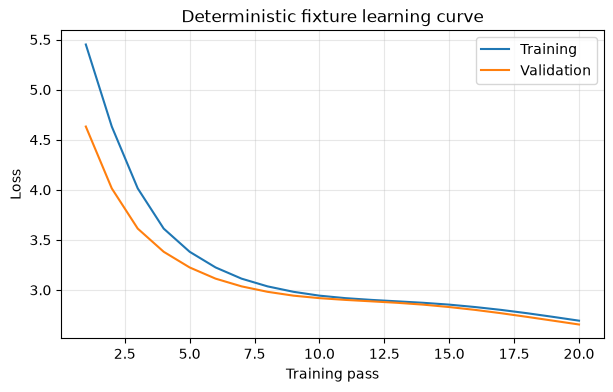

In [8]:
import matplotlib.pyplot as plt

pass_numbers = range(1, NUM_EPOCHS + 1)

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(pass_numbers, training_losses, label="Training")
axis.plot(pass_numbers, validation_losses, label="Validation")
axis.set_xlabel("Training pass")
axis.set_ylabel("Loss")
axis.set_title("Deterministic fixture learning curve")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

## Run the fixture in a fresh process

A notebook kernel can hide missing imports or stale variables. The minimal `transformer-train` entry point constructs its own deterministic model, optimizer, and token tensors, then returns JSON loss histories. Running that command through `subprocess` proves the exported module works without notebook state.


In [9]:
#| export
def _fixture_training_curve(
    number_of_passes: int,
) -> tuple[list[float], list[float]]:
    """Return deterministic training and validation losses for the CLI fixture."""
    if number_of_passes < 1:
        raise ValueError("number_of_passes must be positive")

    torch.manual_seed(1)
    fixture_model = Transformer(
        vocab_size=32,
        d_model=8,
        num_heads=2,
        d_ff=16,
        max_length=8,
        pad_token_id=0,
        dropout=0.0,
        num_layers=6,
    )
    fixture_optimizer = torch.optim.Adam(
        fixture_model.parameters(),
        lr=1e-3,
        betas=(0.9, 0.98),
        eps=1e-9,
    )
    fixture_batches = [
        (
            torch.tensor([[2, 5, 6, 3]], dtype=torch.long),
            torch.tensor([[2, 7, 8, 3]], dtype=torch.long),
        )
    ]

    training_losses: list[float] = []
    validation_losses: list[float] = []
    for _ in range(number_of_passes):
        training_losses.append(
            train(fixture_model, fixture_batches, fixture_optimizer)
        )
        validation_losses.append(validate(fixture_model, fixture_batches))

    return training_losses, validation_losses


def main(argv: Sequence[str] | None = None) -> int:
    """Run deterministic fixture training in a fresh process."""
    parser = argparse.ArgumentParser(description=main.__doc__)
    parser.add_argument("--passes", type=int, default=20)
    args = parser.parse_args(argv)
    number_of_passes = cast(int, args.passes)
    training_losses, validation_losses = _fixture_training_curve(
        number_of_passes
    )
    print(
        json.dumps(
            {
                "training_losses": training_losses,
                "validation_losses": validation_losses,
            }
        )
    )
    return 0


### Fresh-process result

The command below runs eight short fixture passes. Its standard output is parsed as JSON and plotted, so successful output demonstrates both the process boundary and the learning trend.


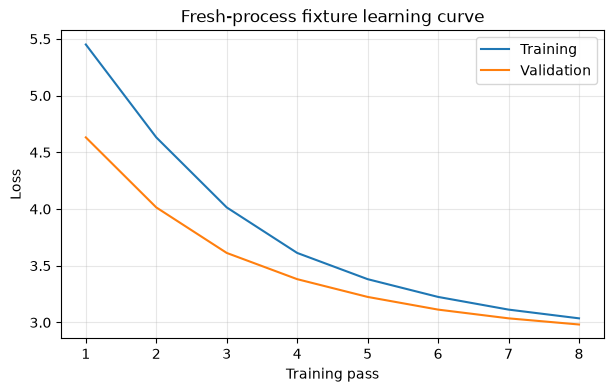

Fresh process completed: training 5.4506 -> 3.0360, validation 4.6315 -> 2.9816


In [10]:
import shutil
import subprocess

training_command = shutil.which("transformer-train")
assert training_command is not None

completed_process = subprocess.run(
    [training_command, "--passes", "8"],
    check=True,
    capture_output=True,
    text=True,
)
fresh_process_result = cast(
    dict[str, list[float]],
    json.loads(completed_process.stdout),
)
fresh_training_losses = fresh_process_result["training_losses"]
fresh_validation_losses = fresh_process_result["validation_losses"]

assert completed_process.returncode == 0
assert len(fresh_training_losses) == len(fresh_validation_losses) == 8
assert fresh_training_losses[-1] < fresh_training_losses[0]
assert fresh_validation_losses[-1] < fresh_validation_losses[0]

fresh_pass_numbers = range(1, len(fresh_training_losses) + 1)
figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(fresh_pass_numbers, fresh_training_losses, label="Training")
axis.plot(fresh_pass_numbers, fresh_validation_losses, label="Validation")
axis.set_xlabel("Training pass")
axis.set_ylabel("Loss")
axis.set_title("Fresh-process fixture learning curve")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

print(
    "Fresh process completed: "
    f"training {fresh_training_losses[0]:.4f} -> {fresh_training_losses[-1]:.4f}, "
    f"validation {fresh_validation_losses[0]:.4f} -> "
    f"{fresh_validation_losses[-1]:.4f}"
)


## Explicitly deferred

Checkpoint persistence and restart belong to notebook 06. Mixed precision, WMT-scale data, the Noam schedule wiring, gradient accumulation, and campaign configuration belong to calibration and canonical-training notebooks. Trainer frameworks, experiment databases, rich metrics schemas, and distributed execution remain out of scope.


## Completion evidence

The notebook demonstrates that training updates parameters, validation preserves them, repeated passes reduce fixture loss, and the exported command completes in a fresh process. The same fixture is intentionally used for training and validation; these curves demonstrate execution and mode boundaries, not generalization to unseen data.
